In [1]:
import os
import sys
os.environ["JAX_PLATFORM_NAME"] = "gpu"

import jax
import jax.numpy as jnp
import flax.linen as nn
import netket as nk
import optax
import numpy as np
import matplotlib.pyplot as plt
import json
import flax.serialization as serialization
from tqdm import tqdm

print(jax.devices())

import importlib
try:
    importlib.reload(sys.modules["src_renyi"])
except KeyError: 
    pass
from src_renyi import (
    ARNN_Z2, RBM_Z2,
    free_energy_minimize_SR_SGD,
    free_energy_minimize,
    free_energy_minimize_scipy,
    FreeRenyiEnergyObservable
)

[CudaDevice(id=0)]


In [2]:
# Hilbert space
from netket.hilbert import Spin
N = 30
N_ancilla = 30
partition = list(range(N))

# System: N 1/2
# Ancilla: N_ancilla  1/2
# Total space = spin ⊗ ancilla
hi_system = nk.hilbert.Spin(s=1/2, N=N)
hi_ancilla = nk.hilbert.Spin(s=1/2, N=N_ancilla)
hi_extended = nk.hilbert.Spin(s=1/2, N=N+N_ancilla)

partition = list(range(N)) 

$\mathcal{H_0}=Γ \sum_{i}\sigma_i^{(x)}+V\sum_{i}\sigma_i^{(z)}\sigma_{i+1}^{z} \qquad \mathcal{H_R}=\mathbb{I}_R$

$\mathcal{H}=\mathcal{H_0}\otimes\mathbb{I}_R$

In [3]:
# Pauli matrices import, Hamiltonian  H = H_0 ⊗ I_R
from netket.operator.spin import sigmax, sigmaz
Gamma = -1.5  
V = -1
H_system=0
H_extended = 0

for i in range(N):
    H_system += Gamma * sigmax(hi_system, i)
    H_system += V * sigmaz(hi_system, i) @ sigmaz(hi_system, (i + 1) % N)

for i in range(N):
    H_extended += Gamma * sigmax(hi_extended, i)
    H_extended += V * sigmaz(hi_extended, i) @ sigmaz(hi_extended, (i + 1) % N)

$F_R=\langle H \rangle -TS_2$

Necesitamos una función que calcule $S_2$ y su gradiente. Utilizaremos:

$S_2=-\log(Tr(\rho_A^2))=-\log\left\langle\frac{\psi(r,\eta')\psi(r',\eta)}{\psi(r,\eta)\psi(r',\eta')}\right\rangle$

Quantum Neural Network training at a given temperature

Step    0 | F=-29.494928 | t=7.828s
Step   20 | F=-38.568123 | t=1.929s
Step   40 | F=-38.981894 | t=2.299s
Step   60 | F=-39.169246 | t=2.052s
Step   80 | F=-40.032550 | t=1.903s
Step  100 | F=-35.480042 | t=1.903s
Step  120 | F=-40.285921 | t=2.103s
Step  140 | F=-39.421916 | t=2.075s
Step  160 | F=-39.806946 | t=2.077s
Step  180 | F=-40.088642 | t=2.074s
Step  200 | F=-35.929579 | t=2.088s
Step  220 | F=-37.381428 | t=2.083s
Step  240 | F=-35.522772 | t=2.078s
Step  260 | F=-40.519134 | t=2.149s
Step  280 | F=-40.721283 | t=2.199s


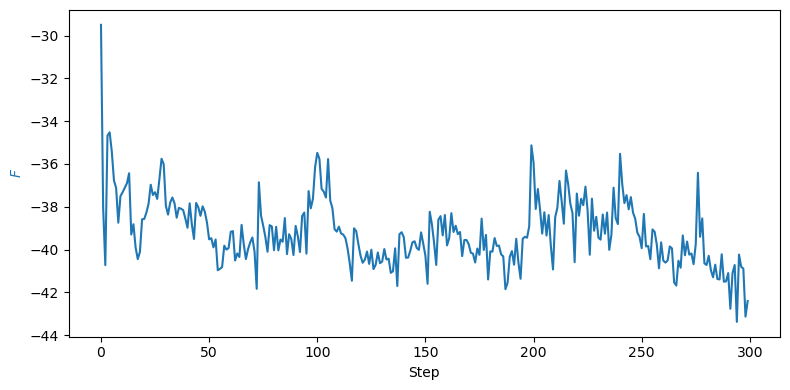

Best solution: S₂=10.056495, E=-23.334396, F=-41.436087


In [12]:
sampler = nk.sampler.ARDirectSampler(hi_extended)

arnn = nk.models.ARNNDense(hilbert=hi_extended, layers=1, features=16, activation=jax.nn.gelu)
model = ARNN_Z2(worker=arnn, trivial_Z2=True)
vstate = nk.vqs.MCState(sampler, arnn, n_samples=40960*4)
T = 1.8

n_steps = 300
lr = optax.linear_schedule(0.05, 0.001, n_steps)
diag_shift = optax.linear_schedule(1e-1, 1e-4, n_steps)
_,f_best,E_best,S_best = free_energy_minimize_SR_SGD(vstate, T, partition, H_extended, n_steps, learning_rate=lr,
                                                      diag_shift=diag_shift, freq=20, timing=True, n_samples_sr=4096,
                                                      chunk_size=vstate.n_samples//4)
print(f"Best solution: S₂={S_best:.6f}, E={E_best:.6f}, F={f_best:.6f}")

In [37]:
sampler = nk.sampler.ARDirectSampler(hi_extended)
arnn = nk.models.ARNNDense(hilbert=hi_extended, layers=1, features=16, activation=jax.nn.gelu)
model = ARNN_Z2(worker=arnn, trivial_Z2=True)
vstate = nk.vqs.MCState(sampler, arnn, n_samples=2**19)
n_steps = 300
lr = optax.linear_schedule(0.05, 0.005, n_steps)
optimizer = optax.sign_sgd(lr)
sr = nk.optimizer.SR(diag_shift=optax.linear_schedule(1e-1, 1e-4, n_steps))
T = 2
_,f_best,E_best,S_best = free_energy_minimize(vstate, T, partition, H_extended, n_steps, freq=20,
                                               optimizer=optimizer, learning_rate=lr, clip_norm=None, timing=True,
                                               chunk_size=vstate.n_samples//16, sr=None, n_samples_sr=4096)
print(f"Best solution: S₂={S_best:.6f}, E={E_best:.6f}, F={f_best:.6f}")

2026-04-14 17:02:28.292344: W external/xla/xla/tsl/framework/bfc_allocator.cc:501] Allocator (GPU_0_bfc) ran out of memory trying to allocate 968.00MiB (rounded to 1015023616)requested by op 
2026-04-14 17:02:28.292558: W external/xla/xla/tsl/framework/bfc_allocator.cc:512] **___________________***********________________*****x_________********_______*********************x
E0414 17:02:28.292576  315129 pjrt_stream_executor_client.cc:3077] Execution of replica 0 failed: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 1015023536 bytes. [tf-allocator-allocation-error='']


XlaRuntimeError: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 1015023536 bytes.

Training at different temperatures

In [ ]:
sampler = nk.sampler.ARDirectSampler(hi_extended)
model = nk.models.ARNNDense(hilbert=hi_extended, layers=1, features=16, activation=jax.nn.gelu)
vstate = nk.vqs.MCState(sampler, model, n_samples=40960*4)

T_array = np.linspace(0, 4, 41)
n_steps = 330
lr = optax.linear_schedule(0.05, 0.005, n_steps)

energy_results = []
entropy_results = []
free_energy_results = []
all_histories = []
best_params = None
os.makedirs(f"../data/N{N}/params", exist_ok=True)

for T_idx, T in enumerate(tqdm(T_array, desc="Temperaturas")):
    print(f"\n=== Temperatura T = {T:.3f} ===")

    vstate.init_parameters()
    # if best_params is not None:
    #     vstate.parameters = best_params
    #     lr = optax.linear_schedule(0.01, 0.001, n_steps)

    free_energy_history, best_F, best_energy, best_entropy = free_energy_minimize(
        vstate=vstate,
        T=T,
        partition=partition,
        Hamiltonian=H_extended,
        n_steps=n_steps,
        verbose=True,
        plot = False,
        optimizer=optax.sign_sgd(learning_rate=lr),
        chunk_size=vstate.n_samples//4
    )
    best_params = vstate.parameters
    filename = f"../data/N{N}/params/params_T_{T:.3f}.msgpack"

    with open(filename, "wb") as f:
        f.write(serialization.to_bytes(best_params))

    energy_results.append(best_energy)
    entropy_results.append(best_entropy)
    free_energy_results.append(best_F)

    all_histories.append({
        "T": T,
        "free_energy": free_energy_history,
    })

    print(f"  Mejor resultado: E={best_energy:.4f}, S₂={best_entropy:.4f}, F={best_F:.4f}")

# Visualización
plt.figure(figsize=(15, 6))

plt.subplot(1, 3, 1)
plt.plot(T_array, energy_results, 'o-')
plt.xlabel('T'); plt.ylabel('Energía'); plt.title('Energía vs Temperatura'); plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(T_array, entropy_results, 's-')
plt.xlabel('T'); plt.ylabel('S₂'); plt.title('Entropía de Rényi-2 vs Temperatura'); plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(T_array, free_energy_results, 'd-')
plt.xlabel('T'); plt.ylabel('F'); plt.title('Energía Libre vs Temperatura'); plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

os.makedirs(f"../data/N{N}", exist_ok=True)

data = {
    "T": [float(T) for T in T_array],
    "energy": [float(x) for x in energy_results],
    "entropy": [float(x) for x in entropy_results],
    "free_energy": [float(x) for x in free_energy_results],
}

with open(f"../data/N{N}/results_N{N}_vs_T.txt", "w") as f:
    json.dump(data, f, indent=2)


Temperaturas:   0%|          | 0/41 [00:00<?, ?it/s]


=== Temperatura T = 0.000 ===
Step    0 | F=-44.714271
Step   50 | F=-50.156474
Step  100 | F=-50.156855
Step  150 | F=-50.156940
Step  200 | F=-50.156421
Step  250 | F=-50.157005
Step  300 | F=-50.156354


Temperaturas:   2%|▏         | 1/41 [14:28<9:38:41, 868.05s/it]

  Mejor resultado: E=-50.1572, S₂=0.0000, F=-50.1572

=== Temperatura T = 0.100 ===
Step    0 | F=-44.824925
Step   50 | F=-50.156585
Step  100 | F=-50.157015
Step  150 | F=-50.156919
Step  200 | F=-50.156592
Step  250 | F=-50.156800
Step  300 | F=-50.157107


Temperaturas:   5%|▍         | 2/41 [29:00<9:25:47, 870.46s/it]

...

  Mejor resultado: E=-45.7741, S₂=4.3992, F=-51.4931

=== Temperatura T = 1.400 ===
Step    0 | F=-44.906453
Step   50 | F=-48.956900
Step  100 | F=-43.220047
Step  150 | F=-42.900194
Step  200 | F=-46.630104
Step  250 | F=-49.529755
Step  300 | F=-51.134227


Temperaturas:  37%|███▋      | 15/41 [4:07:26<8:08:41, 1127.73s/it]

  Mejor resultado: E=-46.7875, S₂=3.5573, F=-51.7677

=== Temperatura T = 1.500 ===
Step    0 | F=-44.892523
Step   50 | F=-46.036144
Step  100 | F=-35.002708
Step  150 | F=-41.332604
Step  200 | F=-44.358051


Temperaturas:  37%|███▋      | 15/41 [4:19:22<7:29:34, 1037.48s/it]


KeyboardInterrupt: 

Scipy minimization

In [ ]:
model = RBM_Z2(alpha=1, trivial_Z2=True)
vstate = nk.vqs.FullSumState(hilbert=hi_extended, model=model)
vstate.init_parameters

result = free_energy_minimize_scipy(
    vstate,
    T=0.9,
    partition=partition,
    Hamiltonian=H_extended,
    method="BFGS",
    options={"maxiter": 10000},
    verbose=False
)

print(result["result"].success)
print(f"Best F={result['best_F']:.6f}, E={result['best_energy']:.6f}, S₂={result['best_entropy']:.6f}")

In [ ]:
T_array_scipy = np.linspace(0, 10, 60)
model = RBM_Z2(alpha=1, trivial_Z2=True)

energy_results_scipy = []
entropy_results_scipy = []  
free_energy_results_scipy = []

for T in T_array_scipy:
    vstate = nk.vqs.FullSumState(hilbert=hi_extended, model=model) 
    result = free_energy_minimize_scipy(
        vstate,
        T=T,
        partition=partition,
        Hamiltonian=H_extended,
        method="L-BFGS-B",
        options={"maxiter": 50000},
        verbose=False
    )
    energy_results_scipy.append(result["best_energy"])
    entropy_results_scipy.append(result["best_entropy"])
    free_energy_results_scipy.append(result["best_F"])
    print(f"T={T:.3f} -- F={result['best_F']:.6f}, E={result['best_energy']:.6f}, S₂={result['best_entropy']:.6f}, {result['result'].success}")

plt.plot(T_array_scipy, free_energy_results_scipy, label=r"$F$")
plt.plot(T_array_scipy, energy_results_scipy, label=r"$\langle H\rangle$")
plt.plot(T_array_scipy, entropy_results_scipy, label=r"$S_2$")
plt.legend()
plt.show()

In [ ]:
#Comparar con scipy
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

ax1.scatter(T_array, free_energy_results, color="Blue", s=10, alpha=0.5, label="RBM")
ax1.plot(T_array_scipy, free_energy_results_scipy, color="Blue", label="Scipy")
ax1.set_xlabel("T")
ax1.set_ylabel("$F$")
ax1.set_title("Free energy")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.scatter(T_array, energy_results, color="Orange", s=10, alpha=0.5, label="RBM")
ax2.plot(T_array_scipy, energy_results_scipy, color="Orange", label="Scipy")
ax2.set_xlabel("T")
ax2.set_ylabel("$<H>$")
ax2.set_title("$Energy$")
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3.scatter(T_array, entropy_results, color="Green", s=10, alpha=0.5, label="RBM")
ax3.plot(T_array_scipy, entropy_results_scipy, color="Green", label="Scipy")
ax3.set_xlabel("T")
ax3.set_ylabel("$S_2$")
ax3.set_title("Entanglement entropy")
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()